# Introduction
<b>AI201</b><br /> 
<b>Programming Assignment 2</b><br /> 
<b>Naive Bayes Spam Filter</b><br /> 
Instructor(s): Dr. Pros Naval & Dr. Lyn Gabud<br /> 
Name: Deomary Angelo Franco<br />


The famous spam filtering algorithm using naive bayes classifier will be implemented here.

# Import

In [7]:
from collections import Counter
# import csv
import os
import re
import shutil
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

# Useful Functions

In [33]:
def get_email_content(filedir, parent):
    """
    Gets the email contents from the directory relative to the parent.
    """
    filedir = parent / filedir
    with open(filedir, errors='ignore') as f:
        lines = f.readlines()

    return ''.join(lines)


def train_test_split(X, y, train_size=0.75, random_state=42):
    """
    A simple implementation of splitting the dataset (roughly patterned after
    scikit-learn's train_test_split). It gets the indices for each class,
    divides the indices to train_indices and test_indices, according to the 
    preferred train_size, and then shuffles them.
    """
    rng = np.random.default_rng(seed=random_state)
    train_indices = np.array([], dtype=int)
    test_indices = np.array([], dtype=int)

    for class_ in y.unique():
        class_idx = y[y==class_].index.to_numpy()
        rng.shuffle(class_idx)

        n = len(class_idx)
        train_n = int(n * train_size)
        
        train_indices = np.append(train_indices, class_idx[:train_n])
        test_indices = np.append(test_indices, class_idx[train_n:])

    train_indices = rng.permutation(train_indices)
    test_indices = rng.permutation(test_indices)

    X_train = X.iloc[train_indices].copy()
    X_test = X.iloc[test_indices].copy()
    y_train = y.iloc[train_indices].copy()
    y_test = y.iloc[test_indices].copy()

    return X_train, X_test, y_train, y_test


def extract_words(text):
    """
    Parses words into a list.
    """
    word_pattern = r'\b[a-zA-Z]+\b'
    return re.findall(word_pattern, text.lower())


def create_vocabulary(email_frame):
    """
    Returns a vocabulary (a Counter) of words based from a given dataframe.
    """
    email_word_list = email_frame.apply(extract_words)
    # Note here that only the unique "words" are taken from each email 
    # (e.g. "dog bark bark" only returns ["dog", "bark"]) 
    words = [word for words in email_word_list for word in set(words)]
    vocabulary = Counter(words)
    return vocabulary


def p_word_given_classs(
        words_in_class,
        cardinality_d, 
        cardinality_v, 
        lambda_=0
):
    """
    Returns the likelihood of a word. Add lambda_ for Lambda Smoothing.
    """
    numerator = words_in_class + lambda_
    denominator = cardinality_d + lambda_ * cardinality_v
    likelihood = numerator / denominator
    return likelihood


def spam_or_ham(
        email_content,
        vocabulary_spam,
        vocabulary_ham,
        prior_spam,
        prior_ham,
        cardinality_spam, 
        cardinality_ham,
        lambda_=0.005,
        return_prob=False
):
    """
    Returns spam or ham depending on the contents of the email using Naive
    Bayes. Decision is based on the maximum between the summation(logP(x|w)) + 
    logP(w) of w=spam and w=ham.
    """
    cardinality_v = cardinality_spam + cardinality_ham

    # solve for summation of logp(x|spam) + logp(spam)
    p_x_given_spam_log = np.sum(
        [
            np.log10(
                p_word_given_classs(vocabulary_spam.get(word, 0), 
                                    cardinality_spam,
                                    cardinality_v,
                                    lambda_)
            )
            for word in extract_words(email_content)
        ]
    ) + np.log10(prior_spam)

    # solve for summation of logp(x|ham) + logp(ham)
    p_x_given_ham_log = np.sum(
        [
            np.log10(
                p_word_given_classs(vocabulary_ham.get(word, 0), 
                                    cardinality_ham,
                                    cardinality_v,
                                    lambda_)
            ) 
            for word in extract_words(email_content)
        ]
    ) + np.log10(prior_ham)

    prediction = 'spam' if p_x_given_spam_log > p_x_given_ham_log else 'ham'
    if return_prob:
        return p_x_given_spam_log, p_x_given_ham_log
  
    return prediction


def precision_recall(prediction, actual):
    """
    Return a tuple in the form (precision, recall).
    """
    tp = ((prediction == actual) & (prediction == 'spam')).sum()
    tn = ((prediction == actual) & (prediction == 'ham')).sum()
    fp = ((prediction != actual) & (prediction == 'spam')).sum()
    fn = ((prediction != actual) & (prediction == 'ham')).sum()

    precision = tp/(tp+fp)
    recall = tp/(tp+fn)

    return precision, recall


def mutual_information(
        word, 
        vocabulary_spam, 
        vocabulary_ham, 
        cardinality_spam, 
        cardinality_ham,
        prior_spam,
        prior_ham,
        lambda_=0
):
    """
    Calculates the Mutual Information MI(X; C) of a given word. For this use
    case, the equation is simplified to be the sum of 4 terms namely 
    present_spam_mi, present_ham_mi, absent_spam_mi, and absent_ham_mi.
    """
    pxgc_spam = p_word_given_classs(
        vocabulary_spam.get(word, 0),
        cardinality_spam, 
        cardinality_spam + cardinality_ham, 
        lambda_=lambda_
    )
    pxgc_ham = p_word_given_classs(
        vocabulary_ham.get(word, 0),
        cardinality_ham, 
        cardinality_spam + cardinality_ham, 
        lambda_=lambda_
    )
    
    px_present = pxgc_spam * prior_spam + pxgc_ham * prior_ham
    present_spam_mi = pxgc_spam * prior_spam * np.log2(pxgc_spam/px_present)
    present_ham_mi = pxgc_ham * prior_ham * np.log2(pxgc_ham/px_present)
    absent_spam_mi = (1-pxgc_spam) * prior_spam * np.log2((1-pxgc_spam)/(1-px_present))
    absent_ham_mi = (1-pxgc_ham) * prior_ham * np.log2((1-pxgc_ham)/(1-px_present))
    mi = present_spam_mi + present_ham_mi + absent_spam_mi + absent_ham_mi
    return max(mi, 0)
    
    
def plot_confusion_matrix(
        prediction, 
        y_test, 
        title='Confusion matrix', 
        cmap=plt.cm.gray_r
):
    """
    Shows the confusion matrix of spam and ham.
    """
    df = pd.crosstab(prediction, 
                     y_test, 
                     rownames=['Actual'], 
                     colnames=['Predicted'])
    
    plt.matshow(df, cmap=cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(df.columns))
    plt.xticks(tick_marks, df.columns, rotation=45)
    plt.yticks(tick_marks, df.index)

    plt.ylabel(df.index.name)
    plt.xlabel(df.columns.name)

    for (i, j), value in np.ndenumerate(df.values):
        plt.text(j, i, f'{value}', ha='center', va='center', color='red')


# Preprocessing

## Preparation of Data
NOTE: Ensure that in the same directory of the script/notebook, there must a folder named  `trec06p-ai201` with the ff. structure: <br>
- [this script]
- /trec06p-ai201
    - /labels
    - /data
        - /000
            - /000
            - /001
            - ...

        - /001
            - /000
            - /001
            - ... 

        - ... 

A dataframe is created containing the parsed email contents and mapped accordingly to its proper label.

See helper functions for:
- `get_email_content`

In [3]:
cwd = Path().cwd()
trec06p = cwd / 'trec06p-ai201'
labels = trec06p / 'labels'

with open(labels, 'r') as f:
    lines = f.readlines()

data = pd.DataFrame(lines, columns=['label_filedir'])
data[['label', 'filedir']] = (
    data['label_filedir']
    .str.replace('\n', '')
    .str.split(' ../', expand=True)
)
data['email_content'] = data['filedir'].apply(
    get_email_content, 
    parent=trec06p
)

In [4]:
data['label'].value_counts()

label
spam    24912
ham     12910
Name: count, dtype: int64

In [5]:
data['label'].value_counts(normalize=True)

label
spam    0.658664
ham     0.341336
Name: proportion, dtype: float64

## Check point. 
Saving parsed data to a csv.

In [6]:
data.to_csv('initial_data.csv', index=False)

In [9]:
data

,label_filedir,label,filedir,email_content
0,ham ../data/000/000\n,ham,data/000/000,Received: from rodan.UU.NET by aramis.rutgers....
1,spam ../data/000/001\n,spam,data/000/001,Received: from unknown (HELO groucho.cs.psu.ed...
2,spam ../data/000/002\n,spam,data/000/002,Received:\n\tfrom 24-151-178-89.dhcp.kgpt.tn.c...
3,ham ../data/000/003\n,ham,data/000/003,Received: from psuvax1.cs.psu.edu ([130.203.2....
4,spam ../data/000/004\n,spam,data/000/004,Received: from 201-1-198-159.dsl.telesp.net.br...
...,...,...,...,...
37817,spam ../data/126/017\n,spam,data/126/017,Received: from ?211.200.1.51? (unknown [211.20...
37818,spam ../data/126/018\n,spam,data/126/018,Received:\n\tfrom dsl.dynamic212156187251.ttne...
37819,spam ../data/126/019\n,spam,data/126/019,Received: from wonder.hananet.net (unknown [21...
37820,spam ../data/126/020\n,spam,data/126/020,Received: from mail.csonline.com (unknown [61....


## Train and Test Split
NOTE: `train_test_split` is not the `scikit-learn` version but a personal implementation that is patterned after the original. This automatically performs stratify according to the labels. To replicate the split, use `random_state`.

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    data[['filedir', 'email_content']], 
    data['label'], 
    train_size=0.7, 
    random_state=42
)

In [42]:
original_dir = trec06p
train_dir = "dataset/train"
test_dir = "dataset/test"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)


In [56]:
for file_path in X_train["filedir"]:
    src_path = os.path.join(original_dir, file_path)
    dest_path = os.path.join(train_dir, file_path)

    os.makedirs(os.path.dirname(dest_path), exist_ok=True)
    
    if os.path.exists(src_path):
        shutil.copy(src_path, dest_path)
    else:
        print(f"Warning: {src_path} not found!")

In [57]:
for file_path in X_test["filedir"]:
    src_path = os.path.join(original_dir, file_path)
    dest_path = os.path.join(train_dir, file_path)

    os.makedirs(os.path.dirname(dest_path), exist_ok=True)
    
    if os.path.exists(src_path):
        shutil.copy(src_path, dest_path)
    else:
        print(f"Warning: {src_path} not found!")

In [62]:
X_train, X_test = X_train['email_content'], X_test['email_content']

## Initialize values

Vocabulary (using `Counter`) to store different words with their respective counts. Prior values and cardinalities are also prepared and stored.

See helper functions for:
- `create_vocabulary`

In [63]:
vocabulary_all = create_vocabulary(X_train)
vocabulary_spam = create_vocabulary(X_train[y_train=='spam'])
vocabulary_ham = create_vocabulary(X_train[y_train=='ham'])

prior = y_train.value_counts(normalize=True)
prior_spam = prior['spam']
prior_ham = prior['ham']

cardinality_spam = (y_train=='spam').sum()
cardinality_ham = (y_train=='ham').sum()

In [64]:
print(f'Prior(Spam): {prior_spam:.4f}')
print(f'Prior(Ham): {prior_ham:.4f}')
print(f'Vocabulary Cardinality: {len(vocabulary_all)}')

Prior(Spam): 0.6587
Prior(Ham): 0.3413
Vocabulary Cardinality: 238396


# Naive Bayes Prediction
From the `X_test`, we will predict if the emails are spam or ham and store it in `predictions` to compare it with `y_test`.

See helper functions for:
- `spam_or_ham`

In [65]:
lambda_precision_recall = {
    2.0: [], 
    1.0: [], 
    0.5: [], 
    0.1: [], 
    0.005: [], 
}

t1 = time.time()
for lambda_ in lambda_precision_recall.keys():
    prediction = X_test.apply(
        spam_or_ham,
        vocabulary_spam=vocabulary_spam,
        vocabulary_ham=vocabulary_ham,
        prior_spam=prior_spam,
        prior_ham=prior_ham,
        cardinality_spam=cardinality_spam, 
        cardinality_ham=cardinality_ham,
        lambda_=lambda_
    )
    precision, recall = precision_recall(prediction, y_test)
    lambda_precision_recall[lambda_].append(precision)
    lambda_precision_recall[lambda_].append(recall)

t2 = time.time()
print(f'Time: {t2-t1:.5f} seconds')

Time: 168.67992 seconds


## Plot Precision and Recall vs lambda
The different precision and recall values for the the predicted data is presented below with the confusion matrix. As shown, increasing the lambda value decreases precision but increases recall. A balance of the two is found near the intersection point of the two curves (lambda=0.1). This is subjectively considered the best compromise.

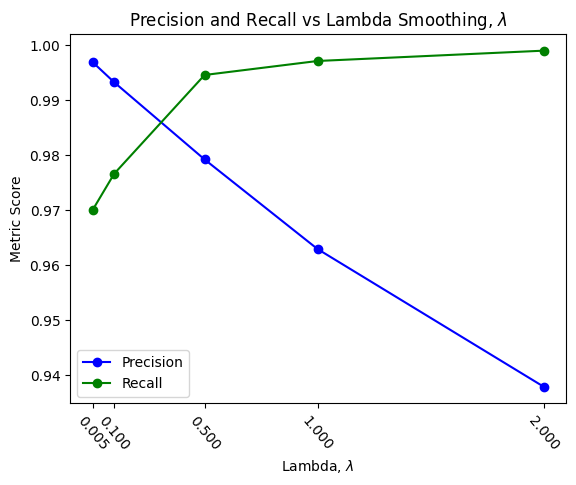

In [66]:
lpr_df = (pd.DataFrame(lambda_precision_recall)
          .T
          .reset_index(names='lambda')
          .rename(columns={0:'precision', 1:'recall'}))

plt.plot(lpr_df['lambda'], lpr_df['precision'], 'bo-', label='Precision')
plt.plot(lpr_df['lambda'], lpr_df['recall'], 'go-', label='Recall')
plt.xlabel(r'Lambda, $\lambda$')
plt.ylabel('Metric Score')
plt.title(r'Precision and Recall vs Lambda Smoothing, $\lambda$')
plt.xticks(lpr_df['lambda'], rotation=310)
plt.legend()
plt.savefig("pr_lambda.png", dpi=300, bbox_inches='tight')


## Best Lambda value
The lambda selected is 0.1 where both precision and recall is around ~95%.

See helper functions for:
- `spam_or_ham`
- `precision_recall`

In [67]:
prediction = X_test.apply(
    spam_or_ham,
    vocabulary_spam=vocabulary_spam,
    vocabulary_ham=vocabulary_ham,
    prior_spam=prior_spam,
    prior_ham=prior_ham,
    cardinality_spam=cardinality_spam, 
    cardinality_ham=cardinality_ham,
    lambda_=0.1
)

precision, recall = precision_recall(prediction, y_test)


In [68]:
print(f'At lambda=0.1,\nPrecision: {precision*100:.2f} % \nRecall: {recall*100:.2f} %')

At lambda=0.1,
Precision: 99.32 % 
Recall: 97.66 %


Shown below is the confusion matrix plot. The incorrect predictions (1st and 3rd quadrant) are relatively small when compared to the TRUE POSITIVES and TRUE NEGATIVES.

See helper functions for:
- `plot_confusion_matrix`

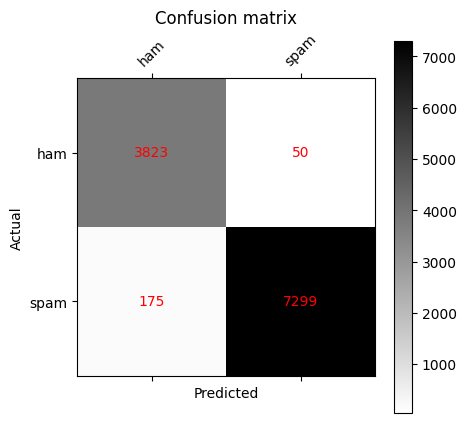

In [69]:
plot_confusion_matrix(y_test, prediction)
plt.savefig("cm_pred.png", dpi=300, bbox_inches='tight')

# Mutual Information
The most informative words will be used to predict if the emails are spam or ham. A score call mutual information is used to rank the top 200 most informative words.

See helper functions for:
- `mutual_information`

In [70]:
vocabulary_mi = {}
for word in vocabulary_all:
    vocabulary_mi[word] = mutual_information(
        word,         
        vocabulary_spam=vocabulary_spam, 
        vocabulary_ham=vocabulary_ham, 
        cardinality_spam=cardinality_spam, 
        cardinality_ham=cardinality_ham,
        prior_spam=prior_spam,
        prior_ham=prior_ham,
        lambda_=.1
    )


Printed in the next cell are the top 200 words, together with their mutual information value.

In [71]:
informative_num = 200
vocabulary_200 = sorted(vocabulary_mi, key=lambda x: vocabulary_mi[x], reverse=True)[:informative_num]
for word in vocabulary_200:
    print(f'{word:<20}: {vocabulary_mi[word]:4f}')

b                   : 0.137555
unknown             : 0.133362
owner               : 0.130062
href                : 0.129559
br                  : 0.113671
head                : 0.108710
meta                : 0.107797
equiv               : 0.106826
com                 : 0.099307
bgcolor             : 0.099082
border              : 0.097809
wrote               : 0.094741
alternative         : 0.094021
p                   : 0.092817
td                  : 0.091968
width               : 0.091948
tr                  : 0.091741
list                : 0.091065
precedence          : 0.091005
boundary            : 0.087862
multipart           : 0.087506
transfer            : 0.087431
encoding            : 0.087096
body                : 0.086663
align               : 0.085952
thanks              : 0.082421
multi               : 0.081604
http                : 0.080109
table               : 0.077020
font                : 0.076558
references          : 0.074179
use                 : 0.073935
if      

In [72]:
(pd.DataFrame([{vocab: vocabulary_mi[vocab] for vocab in vocabulary_200}])
 .T
 .reset_index()
 .rename(columns={'index': 'word', 0: 'MI'})
 .to_csv('top 200 informative words.csv', index=False)
)

In [73]:
vocabulary_spam_200 = vocabulary_spam.keys() & vocabulary_200
vocabulary_spam_200 = {key: vocabulary_spam[key] for key in vocabulary_spam_200}

vocabulary_ham_200 = vocabulary_ham.keys() & vocabulary_200
vocabulary_ham_200 = {key: vocabulary_ham[key] for key in vocabulary_ham_200}

In [74]:
prediction_200 = X_test.apply(
    spam_or_ham,
    vocabulary_spam=vocabulary_spam_200,
    vocabulary_ham=vocabulary_ham_200,
    prior_spam=prior_spam,
    prior_ham=prior_ham,
    cardinality_spam=cardinality_spam, 
    cardinality_ham=cardinality_ham,
    lambda_=.1
)

prediction_200

27205    spam
24613     ham
5322     spam
4303      ham
267       ham
         ... 
25969    spam
37096     ham
29760    spam
26048    spam
17004     ham
Name: email_content, Length: 11347, dtype: object

## Effect of using top 200 most informative words
Only the top 200 words are used in the prediction and the respective precision and recall scores are computed. The lambda is maintain to be 0.1. However, the metrics are now lower, especially the recall, when compared to using the whole available vocabulary. Most of the spam values has been incorrectly classified as not-spam.

See helper functions for:
- `plot_confusion_matrix`

In [75]:
precision_200, recall_200 = precision_recall(prediction_200, y_test)
print(f'At lambda=0.1,\nPrecision: {precision_200*100:.2f} % \nRecall: {recall_200*100:.2f} %')

At lambda=0.1,
Precision: 98.96 % 
Recall: 58.59 %


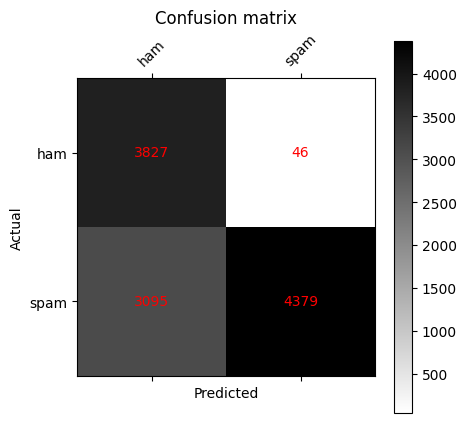

In [76]:
plot_confusion_matrix(y_test, prediction_200)
plt.savefig("cm_pred_200.png", dpi=300, bbox_inches='tight')

# Finding Best Number of Informative Words
Since using only the top 200 words resulted to lower results, it seems the clasifier is underfitting. The next cells will try to understand how the big is the impact of increasing the number of the most informative words.

In [77]:
n_informative = {
    200: [], 
    5000: [],
    10000: [],  
    50000: [], 
    100000: [], 
    len(vocabulary_all): [], 
}

t1 = time.time()
for n in n_informative.keys():

    vocabulary_n = sorted(vocabulary_mi, key=lambda x: vocabulary_mi[x], reverse=True)[:n]
    vocabulary_spam_n = vocabulary_spam.keys() & vocabulary_n
    vocabulary_spam_n = {key: vocabulary_spam[key] for key in vocabulary_spam_n}

    vocabulary_ham_n = vocabulary_ham.keys() & vocabulary_n
    vocabulary_ham_n = {key: vocabulary_ham[key] for key in vocabulary_ham_n}

    prediction_n = X_test.apply(
        spam_or_ham,
        vocabulary_spam=vocabulary_spam_n,
        vocabulary_ham=vocabulary_ham_n,
        prior_spam=prior_spam,
        prior_ham=prior_ham,
        cardinality_spam=cardinality_spam, 
        cardinality_ham=cardinality_ham,
        lambda_=0.1
    )

    precision, recall = precision_recall(prediction_n, y_test)
    n_informative[n].append(precision)
    n_informative[n].append(recall)

t2 = time.time()
print(f'Time: {t2-t1:.5f} seconds')

Time: 170.71557 seconds


As shown below, the general trend when increasing the top informative words for the precision and recall (for a given lambda value) is increasing as it approaches the original count of the vocabulary. However if we inspect further, it can be seen that precision and recall has peaked in between the interval [50000, 100000]. For this case, it can be shown that by using only the top most informative words, we are able to squeeze a better precision and/or recall. Further study may be performed to check what number of top informative words would give the maximum.

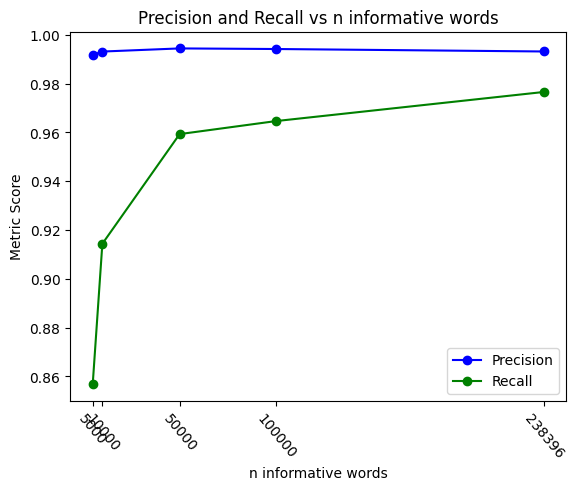

In [78]:
n_informative.pop(200)
ni_df = (pd.DataFrame(n_informative)
          .T
          .reset_index(names='n words')
          .rename(columns={0:'precision', 1:'recall'}))

plt.plot(ni_df['n words'], ni_df['precision'], 'bo-', label='Precision')
plt.plot(ni_df['n words'], ni_df['recall'], 'go-', label='Recall')
plt.xlabel('n informative words')
plt.ylabel('Metric Score')
plt.title('Precision and Recall vs n informative words')
plt.xticks(ni_df['n words'], rotation=310)
# plt.yticks([0.8, 0.9, 1.0])
plt.legend()
plt.savefig("pr_n.png", dpi=300, bbox_inches='tight')